In [1]:
from weylchamber import WeylChamber
from numpy import kron
from scipy.linalg import expm
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import FloatSlider, interact
from numpy.random import Philox
from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate, CZGate, SwapGate, UnitaryGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity, random_unitary
from qiskit.synthesis.two_qubit import TwoQubitWeylDecomposition
from qiskit.visualization import plot_bloch_vector
from qiskit.visualization.state_visualization import _bloch_multivector_data
from qutip import Qobj, sigmax, sigmay, sigmaz, tensor
from scipy.linalg import expm
from weylchamber import c1c2c3
from can_sandwich.bgate import BGate
from tqdm.notebook import tqdm
from qutip import qeye
from qutip.qip.operations import rx, rz

# from qiskit.synthesis.two_qubit.local_invariance
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
SxSx = tensor(sigmax(), sigmax()).full()
SySy = tensor(sigmay(), sigmay()).full()
SzSz = tensor(sigmaz(), sigmaz()).full()


def canonical_gate(a, b, c):
    return expm(np.array(1j * (a * SxSx + b * SySy + c * SzSz)))

In [3]:
# Assuming the zx_noncommuting_invariants function is defined as provided
def zx_noncommuting_invariants(xarg, zphi):
    xarg = 2 * xarg  # times 2 to match canonical gate definition I used

    # G1 calculation
    G1 = (np.cos(xarg) ** 2 + np.cos(zphi) * np.sin(xarg) ** 2) ** 2

    # G2 calculation
    G2 = (1 / 8) * (
        17
        + 4 * np.cos(2 * xarg)
        + 3 * np.cos(4 * xarg)
        + np.cos(2 * zphi) * np.sin(xarg) ** 4
        + np.cos(zphi) * np.sin(2 * xarg) ** 2
    )

    return np.real(G1), np.imag(G1), G2


def zx_noncommuting_weyl(xarg, zphi):
    single_q = Qobj(tensor(rz(zphi), qeye(2)), dims=[[4], [4]])
    u = (
        single_q
        @ Qobj(canonical_gate(xarg, 0, 0))
        @ single_q.dag()
        @ Qobj(canonical_gate(xarg, 0.0, 0)).dag()
    )
    c = list(c1c2c3(u))
    if c[0] > 0.5:
        c[0] = 1 - c[0]
    return c

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:08<00:00,  5.82it/s]


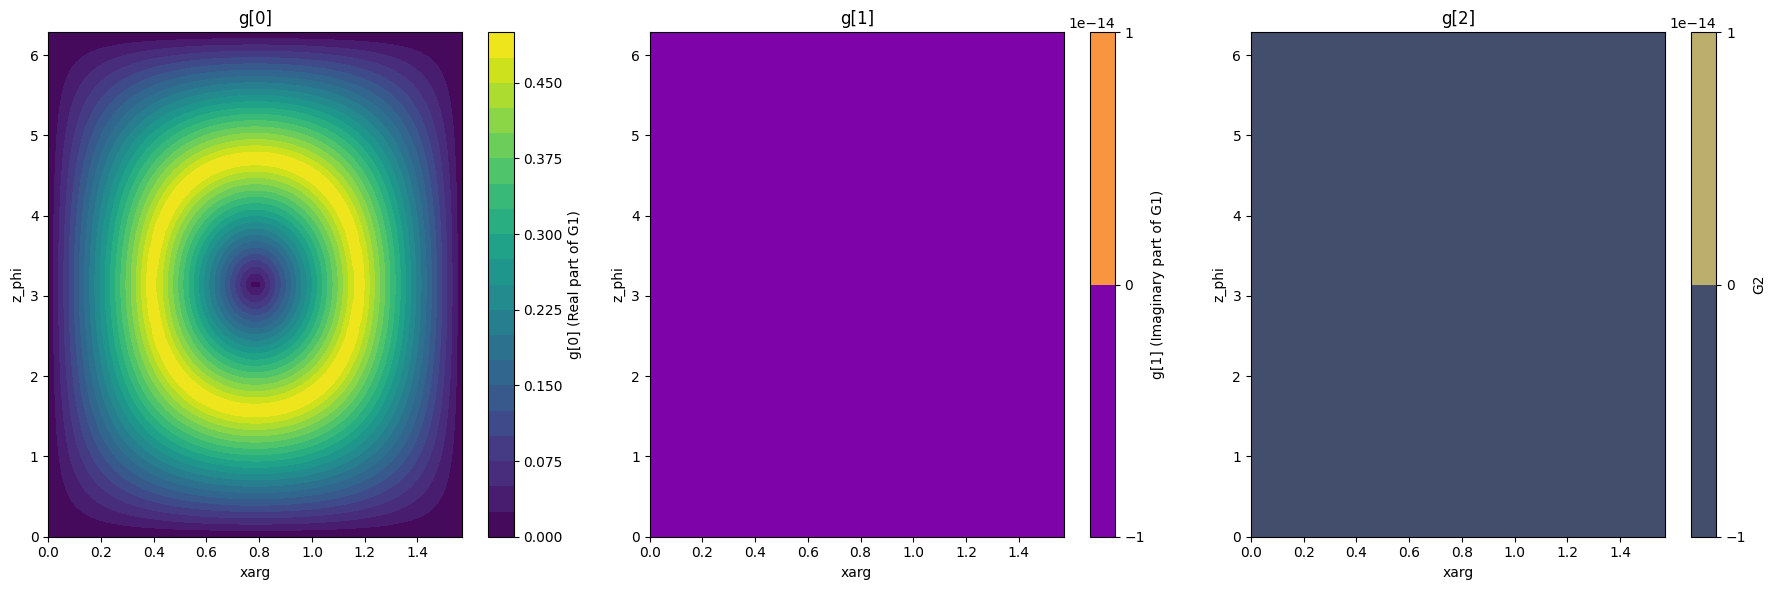

In [8]:
# Define the range of xarg and z_phi values
xarg_values = np.linspace(0, np.pi / 2, 50)  # Range of xarg values
z_phi_values = np.linspace(0, 2 * np.pi, 100)  # Range of z_phi values
coords_real = []
coords_imag = []
coords_G2 = []

# Compute g[0] (real part of G1), g[1] (imaginary part of G1), and G2 over the xarg and z_phi ranges
for xarg in tqdm(xarg_values):
    for zphi in z_phi_values:
        gtuple = zx_noncommuting_weyl(xarg, zphi)
        coords_real.append([xarg, zphi, gtuple[0]])  # Store real part
        coords_imag.append([xarg, zphi, gtuple[1]])  # Store imaginary part
        coords_G2.append([xarg, zphi, gtuple[2]])  # Store G2

# Convert to NumPy arrays for easier handling
coords_real = np.array(coords_real)
coords_imag = np.array(coords_imag)
coords_G2 = np.array(coords_G2)

# Reshape the real, imaginary, and G2 values to match the grid shape
Z_real = coords_real[:, 2].reshape(len(xarg_values), len(z_phi_values)).T
Z_imag = coords_imag[:, 2].reshape(len(xarg_values), len(z_phi_values)).T
Z_G2 = coords_G2[:, 2].reshape(len(xarg_values), len(z_phi_values)).T

# Create the meshgrid for xarg (X) and z_phi (Y)
X, Y = np.meshgrid(xarg_values, z_phi_values)

# Create the plots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot for g[0] (Real part of G1)
c1 = axs[0].contourf(X, Y, Z_real, 20, cmap="viridis")
fig.colorbar(c1, ax=axs[0], label="g[0] (Real part of G1)")
axs[0].set_xlabel("xarg")
axs[0].set_ylabel("z_phi")
axs[0].set_title("g[0]")

# Plot for g[1] (Imaginary part of G1)
c2 = axs[1].contourf(X, Y, Z_imag, 20, cmap="plasma")
fig.colorbar(c2, ax=axs[1], label="g[1] (Imaginary part of G1)")
axs[1].set_xlabel("xarg")
axs[1].set_ylabel("z_phi")
axs[1].set_title("g[1]")

# Plot for G2
c3 = axs[2].contourf(X, Y, Z_G2, 20, cmap="cividis")
fig.colorbar(c3, ax=axs[2], label="G2")
axs[2].set_xlabel("xarg")
axs[2].set_ylabel("z_phi")
axs[2].set_title("g[2]")

plt.tight_layout()
plt.show()

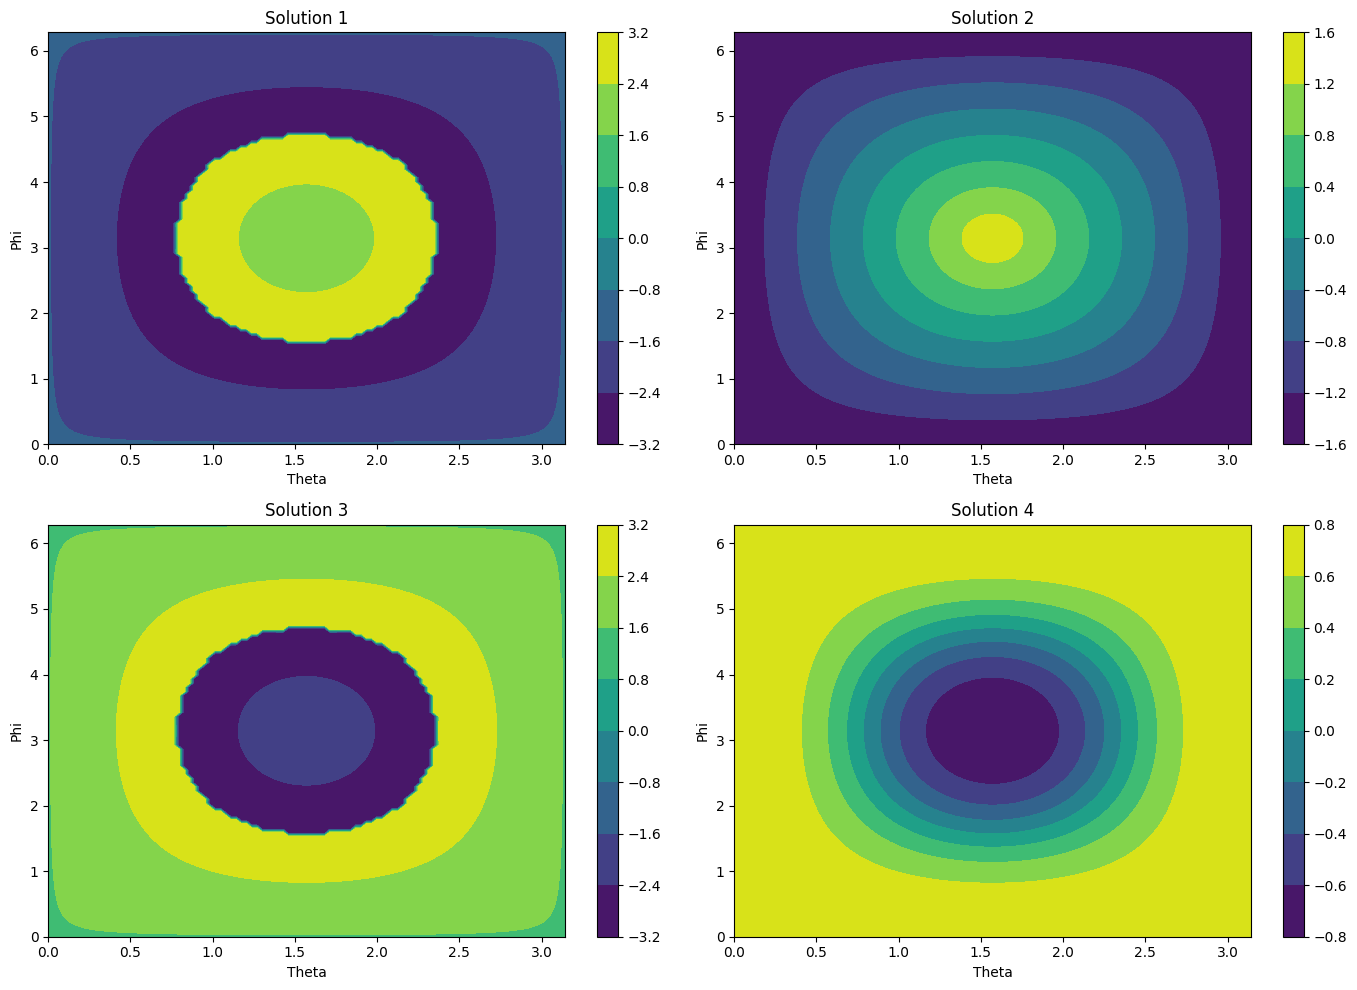

In [10]:
import numpy as np
import matplotlib.pyplot as plt


# Define the functions based on the solutions provided in the Mathematica output.
def c1_solution_1(theta, phi):
    return np.arctan2(
        -4 * (np.cos(theta) ** 2 + np.cos(phi) * np.sin(theta) ** 2),
        -4
        * np.abs(np.sin(theta))
        * np.abs(np.sin(phi / 2))
        * np.sqrt(3 + np.cos(2 * theta) + 2 * np.cos(phi) * np.sin(theta) ** 2),
    )


def c1_solution_2(theta, phi):
    return np.arctan2(
        -4 * (np.cos(theta) ** 2 + np.cos(phi) * np.sin(theta) ** 2),
        4
        * np.abs(np.sin(theta))
        * np.abs(np.sin(phi / 2))
        * np.sqrt(3 + np.cos(2 * theta) + 2 * np.cos(phi) * np.sin(theta) ** 2),
    )


def c1_solution_3(theta, phi):
    return np.arctan2(
        np.cos(theta) ** 2 + np.cos(phi) * np.sin(theta) ** 2,
        -np.abs(np.sin(theta))
        * np.abs(np.sin(phi / 2))
        * np.sqrt(3 + np.cos(2 * theta) + 2 * np.cos(phi) * np.sin(theta) ** 2),
    )


def c1_solution_4(theta, phi):
    return np.arctan(
        np.cos(theta) ** 2
        + np.cos(phi) * np.sin(theta) ** 2  # ,
        # np.abs(np.sin(theta))
        # * np.abs(np.sin(phi / 2))
        # * np.sqrt(3 + np.cos(2 * theta) + 2 * np.cos(phi) * np.sin(theta) ** 2),
    )


# Create a meshgrid for theta and phi values
theta_vals = np.linspace(0, np.pi, 100)
phi_vals = np.linspace(0, 2 * np.pi, 100)

# Generate the grid for plotting
theta_grid, phi_grid = np.meshgrid(theta_vals, phi_vals)

# Evaluate the solutions on the grid
c1_1 = c1_solution_1(theta_grid, phi_grid)
c1_2 = c1_solution_2(theta_grid, phi_grid)
c1_3 = c1_solution_3(theta_grid, phi_grid)
c1_4 = c1_solution_4(theta_grid, phi_grid)

# Plot the solutions
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# First solution
c = axs[0, 0].contourf(theta_vals, phi_vals, c1_1, cmap="viridis")
fig.colorbar(c, ax=axs[0, 0])
axs[0, 0].set_title("Solution 1")

# Second solution
c = axs[0, 1].contourf(theta_vals, phi_vals, c1_2, cmap="viridis")
fig.colorbar(c, ax=axs[0, 1])
axs[0, 1].set_title("Solution 2")

# Third solution
c = axs[1, 0].contourf(theta_vals, phi_vals, c1_3, cmap="viridis")
fig.colorbar(c, ax=axs[1, 0])
axs[1, 0].set_title("Solution 3")

# Fourth solution
c = axs[1, 1].contourf(theta_vals, phi_vals, c1_4, cmap="viridis")
fig.colorbar(c, ax=axs[1, 1])
axs[1, 1].set_title("Solution 4")

# Set labels
for ax in axs.flat:
    ax.set_xlabel("Theta")
    ax.set_ylabel("Phi")

plt.tight_layout()
plt.show()